<a href="https://colab.research.google.com/github/hudamohmand/undergrad_ml_assignments/blob/main/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Assignment 4: Regularization

**Question 1:**

1) Adding a penalty to the mean squared error regularizes the model. Specifically, the penalty will shrink the parameter values and keep the model more simple. This prevents the model from being too complex and it prevents overfitting.
2) Regularization provides us with a balance between bias and variance that in general reduces the complexity of the model.
3) LASSO and Ridge regression are both techniques that address overfitting, specifically utilizing regularization. For both you add a penalty term but for ridge regression you use square values of coefficients, and for LASSO you use absolute values of coefficients. For the answers, using square values of coefficients will give you a coefficient close to zero, but LASSO gives you coefficients that reduce all the way down to zero.
4) To scale variables, we typically use standardization. This means we standardize the variables so that they have a mean of 0 and a standard deviation of 1. We do this so the variables are all on the same scale/addressed equally.
5) The penalty is typically selected with cross-validation. You should use whichever value gives you the lowest error.
6) You should not include the penalty term because that is only used to make the model more simpler, not to evaluate the performance.


**Question 2: Part 1**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV

In [ ]:
data = pd.read_csv("cars_hw.csv")
print(data.head())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  


In [ ]:
data['Age'] = 2024 - data['Make_Year']

In [ ]:
X = data[['Mileage_Run', 'Age']]
y = data['Price']

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

pf = PolynomialFeatures(3)
X_poly = pf.fit_transform(X)

feature_names = pf.get_feature_names_out(['Mileage_Run', 'Age'])
print(feature_names)

['1' 'Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

**Question 2: Part 2**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_scaled, y)

coefs = lr.coef_

for i in range(len(feature_names)):
    print(feature_names[i], coefs[i])

1 0.0
Mileage_Run 668616.5172096733
Age -184194.14613723411
Mileage_Run^2 -149467.87417612973
Mileage_Run Age -1251592.3408260448
Age^2 215639.87875724494
Mileage_Run^3 -65144.89659917663
Mileage_Run^2 Age 283339.1522224272
Mileage_Run Age^2 528082.8634749707
Age^3 -138937.0257937006


What is the sign for the interaction between Mileage_Run and Age? **Answer:** The sign is negative.

**Question 2: Part 3**

In [ ]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_scaled, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13229914430.5, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 131934043991.96875, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 298840628718.6094, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective

LassoCV(alphas=array([  10.        ,   12.74274986,   16.23776739,   20.69138081,
         26.36650899,   33.59818286,   42.81332399,   54.55594781,
         69.51927962,   88.58667904,  112.88378917,  143.84498883,
        183.29807108,  233.57214691,  297.63514416,  379.26901907,
        483.29302386,  615.84821107,  784.75997035, 1000.        ]),
        cv=20)

**Question 2: Part 4**

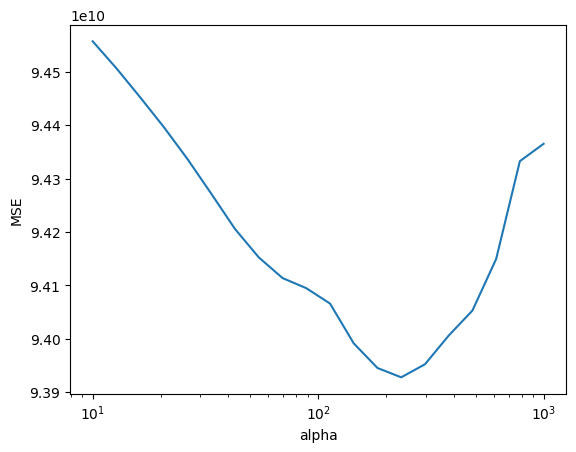

In [ ]:
mse_mean = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mse_mean)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.show()

**Question 2: Part 5**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 40013968376915.625, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 39002042524818.94, tolerance: 12469725702.912619
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 39486304891799.586, tolerance: 12471993172.815535
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWar

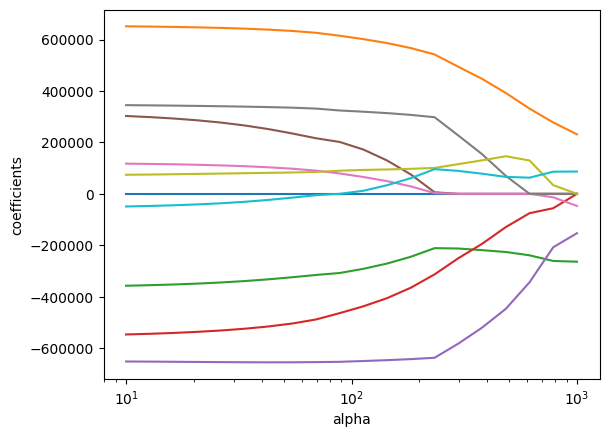

In [ ]:
coefs = []

for a in alphas:
    l = LassoCV(alphas=[a], cv=20)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

for i in range(len(feature_names)):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.show()

**Question 2: Part 6**

In [ ]:
lasso_coefs = lasso.coef_

zero_count = 0

for i in range(len(lasso_coefs)):
    print(feature_names[i], lasso_coefs[i])

    if lasso_coefs[i] == 0:
        zero_count = zero_count + 1

print("Proportion zero:", zero_count / len(lasso_coefs))

1 0.0
Mileage_Run 541816.5548478953
Age -211301.60437084117
Mileage_Run^2 -313330.30331223103
Mileage_Run Age -637593.9365680254
Age^2 5841.326276961901
Mileage_Run^3 2735.7024682341134
Mileage_Run^2 Age 297787.051885324
Mileage_Run Age^2 100600.24240081233
Age^3 95884.58997007925
Proportion zero: 0.1


Which features are actually selected? What proportion are set equal to zero? **Answer:** The features selected are Mileage_Run, and Age. Only one coefficient is set to 0.

**Question 2: Part 7**

Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? **Answer:** The LASSO regression makes most of the coefficients 0, decreasing the magnitude. This helps make the model less complex and prevents overfitting. There are also no major sign changes.

**Question 3: Part 1**

In [ ]:
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")
print(data.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [ ]:
X_cont = data[['age', 'ejection_fraction', 'serum_creatinine']]
X_cat = data[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

y = data['DEATH_EVENT']

In [ ]:
pf_cont = PolynomialFeatures(3)
X_cont_poly = pf_cont.fit_transform(X_cont)

cont_names = pf_cont.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])

In [ ]:
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

In [ ]:
pf_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_inter = pf_cat.fit_transform(X_cat)

cat_names = pf_cat.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])

In [ ]:
X_final = np.concatenate((X_cont_scaled, X_cat_inter), axis=1)

feature_names = list(cont_names) + list(cat_names)

**Question 3: Part 2**

In [ ]:
lr = LinearRegression()
lr.fit(X_final, y)

coefs = lr.coef_

for i in range(len(feature_names)):
    print(feature_names[i], coefs[i])

1 -1.0787429983372465e-13
age 1.539155609361862
ejection_fraction -2.192493664234259
serum_creatinine -0.8535881544612601
age^2 -3.678653925326068
age ejection_fraction -0.6009180269805124
age serum_creatinine 1.8415625716809199
ejection_fraction^2 3.4309764645505156
ejection_fraction serum_creatinine 2.673393621789147
serum_creatinine^2 -2.6470406100691375
age^3 1.9931349422979696
age^2 ejection_fraction 0.908025954110663
age^2 serum_creatinine -0.6975215091976588
age ejection_fraction^2 -0.0812063244537325
age ejection_fraction serum_creatinine -1.5776652636623874
age serum_creatinine^2 1.284099288558629
ejection_fraction^3 -1.2503410525098946
ejection_fraction^2 serum_creatinine -1.270043138964232
ejection_fraction serum_creatinine^2 1.1794749306635648
serum_creatinine^3 0.07215577717302785
anaemia 0.008092533136947466
diabetes -0.07070509612689407
high_blood_pressure -0.007934365189076559
smoking -0.10268659174928721
anaemia diabetes 0.026159483759130374
anaemia high_blood_pressure

Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction? **Answer:** Many coefficients have counterintuitive signs, for example, age has a positive sign, however age^2 has a negative sign while age^3 again has a positive sign. This indicates that the relationship is a bit complex and not easy to interpret. The inclusion of higher-order powers makes the model capture a nonlinear relationship between variables.

**Question 3: Part 3**

In [ ]:
alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_final, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.3070201154248551, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.28938187158850326, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.078673023920139, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Co

LassoCV(alphas=array([1.00000000e-05, 2.21221629e-05, 4.89390092e-05, 1.08263673e-04,
       2.39502662e-04, 5.29831691e-04, 1.17210230e-03, 2.59294380e-03,
       5.73615251e-03, 1.26896100e-02, 2.80721620e-02, 6.21016942e-02,
       1.37382380e-01, 3.03919538e-01, 6.72335754e-01, 1.48735211e+00,
       3.29034456e+00, 7.27895384e+00, 1.61026203e+01, 3.56224789e+01,
       7.88046282e+01, 1.74332882e+02, 3.85662042e+02, 8.53167852e+02,
       1.88739182e+03, 4.17531894e+03, 9.23670857e+03, 2.04335972e+04,
       4.52035366e+04, 1.00000000e+05]),
        cv=20)

**Question 3: Part 4**

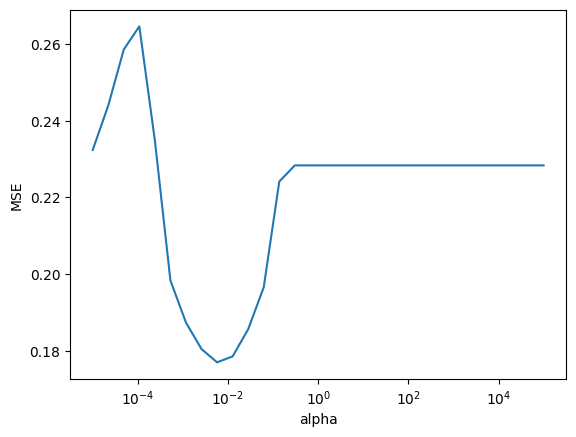

In [ ]:
mse_mean = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mse_mean)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.show()

**Question 3: Part 5**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 18.88280661020108, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 19.003404840686574, tolerance: 0.005874295774647887
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 18.69117361295995, tolerance: 0.005915492957746482
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Conv

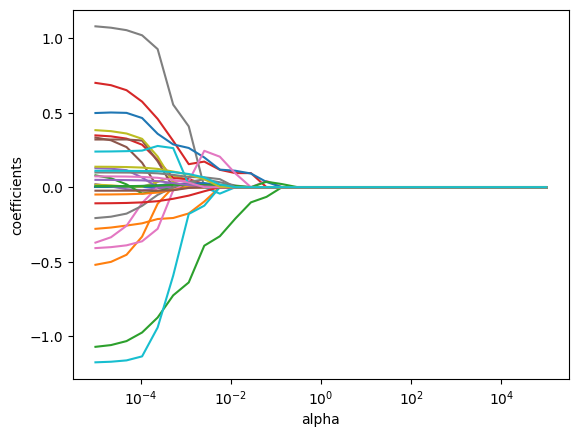

In [ ]:
coefs = []

for a in alphas:
    l = LassoCV(alphas=[a], cv=20)
    l.fit(X_final, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

for i in range(len(feature_names)):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.show()

**Question 3: Part 6**

In [ ]:
lasso_coefs = lasso.coef_

zero_count = 0

for i in range(len(lasso_coefs)):
    print(feature_names[i], lasso_coefs[i])

    if lasso_coefs[i] == 0:
        zero_count = zero_count + 1

print("Proportion zero:", zero_count / len(lasso_coefs))

1 0.0
age -0.0
ejection_fraction -0.32965588260124196
serum_creatinine 0.116875130081409
age^2 0.0
age ejection_fraction -0.0
age serum_creatinine 0.0
ejection_fraction^2 0.0
ejection_fraction serum_creatinine 0.0
serum_creatinine^2 -0.0
age^3 0.11799179769122647
age^2 ejection_fraction 0.0
age^2 serum_creatinine 0.0
age ejection_fraction^2 0.0
age ejection_fraction serum_creatinine 0.0
age serum_creatinine^2 -0.0
ejection_fraction^3 0.2048216381616865
ejection_fraction^2 serum_creatinine 0.032801101897877744
ejection_fraction serum_creatinine^2 -0.0
serum_creatinine^3 -0.04326608283025585
anaemia 0.01417833634447046
diabetes 0.0006065036356018233
high_blood_pressure 0.01360815719195256
smoking -0.0
anaemia diabetes 0.0
anaemia high_blood_pressure 0.0
anaemia smoking 0.0
diabetes high_blood_pressure 0.0539684670228952
diabetes smoking 0.0034664278424864667
high_blood_pressure smoking 0.01780527784500434
Proportion zero: 0.6


Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off. **Answer:** Some features actually selected include ejection_fraction, serum_creatinine, age, and diabetes. About 60% of the coefficients in this case are set to 0. Some coefficients change signs when comparing the linear regressions and optimally regularized coefficients. Age is an example of this. The LASSO model reduces variance and removes many features, because of this, it is the better model compared to the linear regression model.

**Question 4: All Parts**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(np.float64(-0.5), np.float64(1516.5), np.float64(1239.5), np.float64(-0.5))

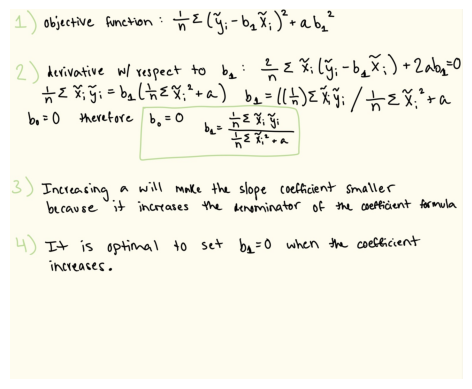

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/drive/MyDrive/IMG_0097.jpeg')
plt.imshow(img)
plt.axis('off')